In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform

from google.colab import drive
drive.mount('/content/gdrive')

path = '/content/gdrive/MyDrive/Colab_Notebooks/'

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# # Fetch historical data for the Hang Seng Index
# start_date = "2019-12-01"
# end_date = "2022-11-30"
# ticker = "^HSI"

# hsi_stock_data = yf.download(ticker, start=start_date, end=end_date)
# hsi_stock_data = hsi_stock_data.reset_index()

In [ ]:
# sentiment_data = pd.read_csv(path+'sentiment_data.csv')
# sentiment_data.sort_values(by='created_at', inplace=True)

# feature_data = pd.read_csv(path+'HSI_OO_ter_0.005.csv')
# feature_data.sort_values(by='Date', inplace=True)

In [ ]:
# hsi_stock_data['Date'] = pd.to_datetime(hsi_stock_data['Date'], format='%Y/%m/%d')
# sentiment_data['created_at'] = pd.to_datetime(sentiment_data['created_at'], format='%Y/%m/%d')
# feature_data['Date'] = pd.to_datetime(feature_data['Date'], format='%Y/%m/%d')

In [ ]:
# full_training_data = hsi_stock_data.merge(sentiment_data, how='left', left_on='Date', right_on='created_at')
# full_training_data = full_training_data.merge(feature_data, how='left', on='Date')
# full_training_data.to_csv('full_training_data.csv', index=False)

In [ ]:
full_training_data = pd.read_csv(path+'full_training_data.csv',index_col=False)

In [ ]:
full_training_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,created_at,wsentiments,HSI_overnight_ret,HSI_intraday_overnight_ret_diff,CSI300_overnight_ret,SSE50_overnight_ret,HSI_stoch_k,HSI_rsi,HSI_daily_ret,HSI_disc_macd_1,HSI_intraday_ret,HSI_ret_range,HSI_OO_ter_0.005
0,2019-12-02,26475.339844,26511.550781,26393.089844,26444.720703,26444.720703,1348911800,2019-12-02,-0.401038,0.004891,-0.006047,0.001787,0.000618,0.235131,44.359677,0.003728,0,-0.001157,0.004496,sell
1,2019-12-03,26315.970703,26424.119141,26063.019531,26391.300781,26391.300781,1795451800,2019-12-03,-0.745256,-0.004869,0.007731,-0.001786,-0.002421,0.281823,43.567513,-0.002020,0,0.002863,0.013655,sell
2,2019-12-04,26071.390625,26191.789062,25995.150391,26062.560547,26062.560547,1502327900,2019-12-04,-0.589029,-0.012122,0.011783,-0.002449,-0.002574,0.054684,38.957026,-0.012456,0,-0.000339,0.007451,sell
3,2019-12-05,26300.509766,26300.509766,26134.060547,26217.039062,26217.039062,1228026600,2019-12-05,-0.709783,0.009130,-0.012304,0.003582,0.004092,0.179999,42.059894,0.005927,0,-0.003174,0.006387,buy
4,2019-12-06,26345.199219,26520.080078,26309.339844,26498.369141,26498.369141,1644211100,2019-12-06,-0.416191,0.004888,0.000926,0.001469,0.002194,0.408219,47.312423,0.010731,1,0.005814,0.008038,neutral


In [ ]:
full_training_data.drop(columns=['created_at', 'wsentiments'], inplace=True)

In [ ]:
min_max_column = ['HSI_overnight_ret', 'HSI_intraday_overnight_ret_diff', 
                     'CSI300_overnight_ret', 'SSE50_overnight_ret', 'HSI_stoch_k', 'HSI_rsi', 
                     'HSI_daily_ret', 'HSI_intraday_ret', 'HSI_ret_range']

In [ ]:
mms = MinMaxScaler()
full_training_data[min_max_column] = mms.fit_transform(full_training_data[min_max_column])

In [ ]:
full_training_data['HSI_OO_ter_0.005'] = full_training_data['HSI_OO_ter_0.005'].map({'buy':1, 'sell':-1, 'neutral':0})

In [ ]:
regression_column = ['HSI_overnight_ret', 'HSI_intraday_overnight_ret_diff', 
                     'CSI300_overnight_ret', 'SSE50_overnight_ret', 'HSI_stoch_k', 'HSI_rsi', 
                     'HSI_daily_ret', 'HSI_disc_macd_1', 'HSI_intraday_ret', 'HSI_ret_range', 
                     'Close']
regression_df = full_training_data[regression_column]

In [ ]:
X = regression_df.drop(['Close'], axis=1)
y = regression_df['Close']

In [ ]:
# Prepare the dataset

# Split the data into training (70%), testing (15%), and validation (15%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, random_state=42)

# Create the XGBoost model with a reduced number of estimators
model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=60, random_state=42)

# Set up the hyperparameter distributions for tuning
param_dist = {
    'max_depth': sp_randint(1, 6),
    'min_child_weight': sp_randint(1, 10),
    'gamma': sp_uniform(0, 1),
    'subsample': sp_uniform(0.4, 0.6),
    'colsample_bytree': sp_uniform(0.4, 0.6),
    'reg_alpha': sp_uniform(0, 3),
    'reg_lambda': sp_uniform(0, 3),
    'learning_rate': sp_uniform(0.005, 0.05)
}

# Perform randomized search with a given number of iterations
n_iter_search = 75
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=n_iter_search, cv=5,
                                   scoring='neg_mean_squared_error', verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)

# Print the best combination of hyperparameters
print("Best hyperparameters found using randomized search:")
print(random_search.best_params_)

# Train the model with the best hyperparameters
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=[(X_val, y_val)], verbose=False)

# Make predictions
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Calculate root mean squared error
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Calculate MAPE
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

# Calculate R2 score
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"RMSE on training set: {rmse_train:.2f}")
print(f"RMSE on testing set: {rmse_test:.2f}")
print(f"MAPE on training set: {mape_train:.2f}")
print(f"MAPE on testing set: {mape_test:.2f}")
print(f"R2 score on training set: {r2_train:.2f}")
print(f"R2 score on testing set: {r2_test:.2f}")

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best hyperparameters found using randomized search:
{'colsample_bytree': 0.8876797403545016, 'gamma': 0.9472485773838587, 'learning_rate': 0.054300053191143546, 'max_depth': 4, 'min_child_weight': 4, 'reg_alpha': 1.1287787565927472, 'reg_lambda': 0.2505021500960063, 'subsample': 0.866288149556462}
RMSE on training set: 2234.06
RMSE on testing set: 3221.78
MAPE on training set: 0.08
MAPE on testing set: 0.11
R2 score on training set: 0.56
R2 score on testing set: 0.11


/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


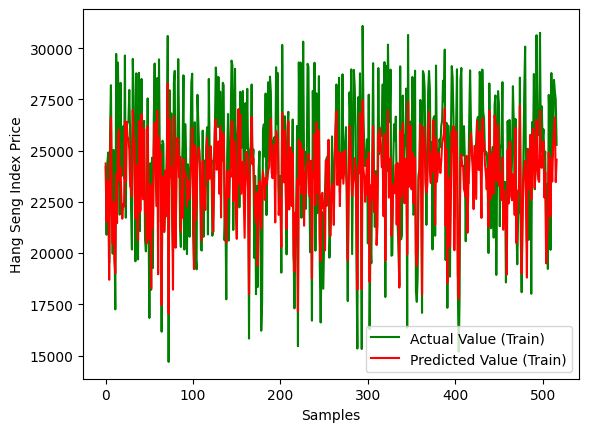

In [ ]:
# Plot actual and predicted stock prices for training data
plt.plot(y_train.reset_index(drop=True), label="Actual Value (Train)", color="green")
plt.plot(pd.Series(y_pred_train), label="Predicted Value (Train)", color="red")
plt.xlabel('Samples')
plt.ylabel('Hang Seng Index Price')
plt.legend()
plt.show()

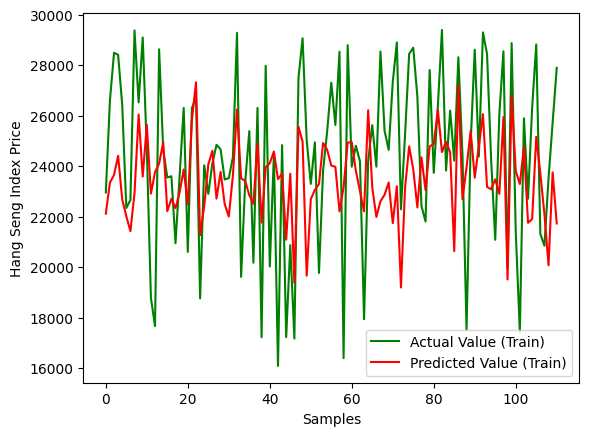

In [ ]:
# Plot actual and predicted stock prices for testing data
plt.plot(y_test.reset_index(drop=True), label="Actual Value (Train)", color="green")
plt.plot(pd.Series(y_pred_test), label="Predicted Value (Train)", color="red")
plt.xlabel('Samples')
plt.ylabel('Hang Seng Index Price')
plt.legend()
plt.show()

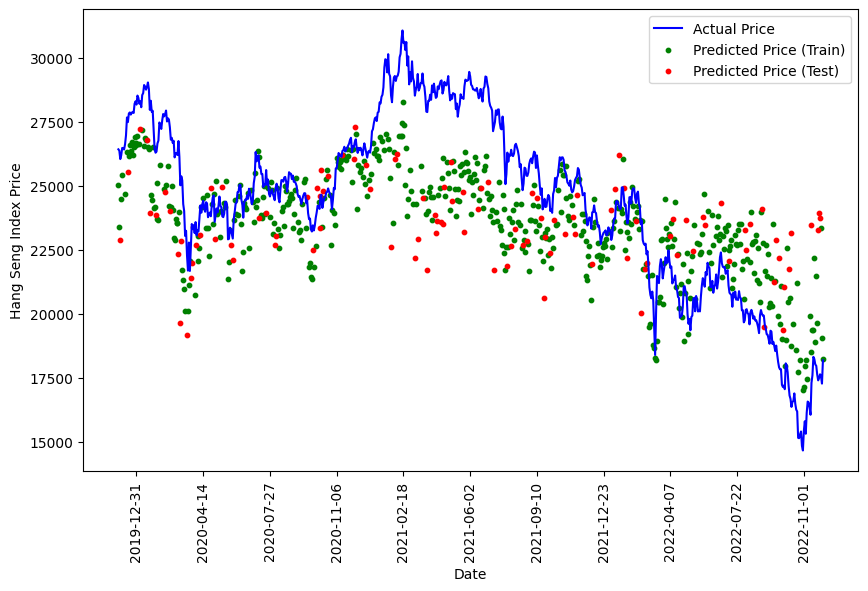

In [ ]:
# Plot the results
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(full_training_data["Date"], full_training_data["Close"], label="Actual Price", color="blue")

# Sort the training, testing, and validation predictions by date
train_pred_df = pd.DataFrame({'Date': full_training_data.loc[X_train.index, 'Date'], 'Predicted': y_pred_train})
test_pred_df = pd.DataFrame({'Date': full_training_data.loc[X_test.index, 'Date'], 'Predicted': y_pred_test})
  
train_pred_df = train_pred_df.sort_values(by='Date').reset_index(drop=True)
test_pred_df = test_pred_df.sort_values(by='Date').reset_index(drop=True)

ax.scatter(train_pred_df["Date"], train_pred_df["Predicted"], label="Predicted Price (Train)", color="green", s=10)
ax.scatter(test_pred_df["Date"], test_pred_df["Predicted"], label="Predicted Price (Test)", color="red", s=10)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=10))
ax.set_ylabel("Hang Seng Index Price")
ax.set_xlabel("Date")
plt.xticks(rotation=90)
ax.legend()
plt.show()

# **Classification**

In [ ]:
classification_column = ['HSI_overnight_ret', 'HSI_intraday_overnight_ret_diff', 
                     'CSI300_overnight_ret', 'SSE50_overnight_ret', 'HSI_stoch_k', 'HSI_rsi', 
                     'HSI_daily_ret', 'HSI_disc_macd_1', 'HSI_intraday_ret', 'HSI_ret_range', 
                     'HSI_OO_ter_0.005']
classification_df = full_training_data[classification_column]

In [ ]:
X = classification_df.drop(['HSI_OO_ter_0.005'], axis=1)
y = classification_df['HSI_OO_ter_0.005']

In [ ]:
# Prepare the dataset

# Split the data into training (70%), testing (15%), and validation (15%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, random_state=42)

# Create the XGBoost model with a reduced number of estimators
model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=60, random_state=42)

# Set up the hyperparameter distributions for tuning
param_dist = {
    'max_depth': sp_randint(1, 6),
    'min_child_weight': sp_randint(1, 10),
    'gamma': sp_uniform(0, 1),
    'subsample': sp_uniform(0.4, 0.6),
    'colsample_bytree': sp_uniform(0.4, 0.6),
    'reg_alpha': sp_uniform(0, 3),
    'reg_lambda': sp_uniform(0, 3),
    'learning_rate': sp_uniform(0.005, 0.05)
}

# Perform randomized search with a given number of iterations
n_iter_search = 75
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=n_iter_search, cv=5,
                                   scoring='neg_mean_squared_error', verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)

# Print the best combination of hyperparameters
print("Best hyperparameters found using randomized search:")
print(random_search.best_params_)

# Train the model with the best hyperparameters
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=[(X_val, y_val)], verbose=False)

# Make predictions
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

y_pred_train = list(map(lambda x: -1 if (x < -0.5) else (0 if (x < 0.5) else 1), y_pred_train))
y_pred_test = list(map(lambda x: -1 if (x < -0.5) else (0 if (x < 0.5) else 1), y_pred_test))

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best hyperparameters found using randomized search:
{'colsample_bytree': 0.4308872507499936, 'gamma': 0.27864646423661144, 'learning_rate': 0.05041329429833268, 'max_depth': 3, 'min_child_weight': 2, 'reg_alpha': 1.5928037499514092, 'reg_lambda': 1.343349493719275, 'subsample': 0.7317358534427968}


/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score
# Calculating the accuracy of classifier
print(f"Accuracy of training: {accuracy_score(y_train, y_pred_train)}")
print(f"Accuracy of testing: {accuracy_score(y_test, y_pred_test)}")

Accuracy of training: 0.6189555125725339
Accuracy of testing: 0.5405405405405406


In [ ]:
# importing all necessary libraries
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion_matrix funnction a matrix containing the summary of predictions
print(confusion_matrix(y_train, y_pred_train))
print(confusion_matrix(y_test, y_pred_test))
# plot_confusion_matrix function is used to visualize the confusion matrix
# plot_confusion_matrix(classifier, X_test, y_test)
# plt.show()

[[ 87  90   2]
 [ 14 126  12]
 [  0  79 107]]
[[18 32  2]
 [ 2 27  2]
 [ 0 13 15]]


In [ ]:

# Importing all necessary libraries
from sklearn.metrics import precision_score

# Calculating the precision score of classifier
print(f"Precision Score of training: {precision_score(y_train, y_pred_train, average=None)}")
print(f"Precision Score of testing: {precision_score(y_test, y_pred_test, average=None)}")

Precision Score of training: [0.86138614 0.42711864 0.88429752]
Precision Score of testing: [0.9        0.375      0.78947368]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_train, y_pred_train, digits=3))
print(classification_report(y_test, y_pred_test, digits=3))

              precision    recall  f1-score   support

          -1      0.861     0.486     0.621       179
           0      0.427     0.829     0.564       152
           1      0.884     0.575     0.697       186

    accuracy                          0.619       517
   macro avg      0.724     0.630     0.627       517
weighted avg      0.742     0.619     0.632       517

              precision    recall  f1-score   support

          -1      0.900     0.346     0.500        52
           0      0.375     0.871     0.524        31
           1      0.789     0.536     0.638        28

    accuracy                          0.541       111
   macro avg      0.688     0.584     0.554       111
weighted avg      0.725     0.541     0.542       111

